## 1. Problem Statement
Customer Segmentation using K-Means (Telco Dataset)

Objective:
Segment telecom customers into meaningful groups using unsupervised learning (K-Means clustering)
to support business decision-making such as retention, targeting, and personalization.

### 🔹 2. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

### 🔹 3. Load Dataset

In [2]:

url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/telco-customer-churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Data Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 🔹 5. Data Cleaning

In [4]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Drop ID column
df.drop('customerID', axis=1, inplace=True)

## 6. Feature Selection (Clustering Focus)

In [5]:
# For clustering, we use numerical behavioral features
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features]

## 7. Feature Scaling

In [6]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 8. Elbow Method (Find Optimal K)

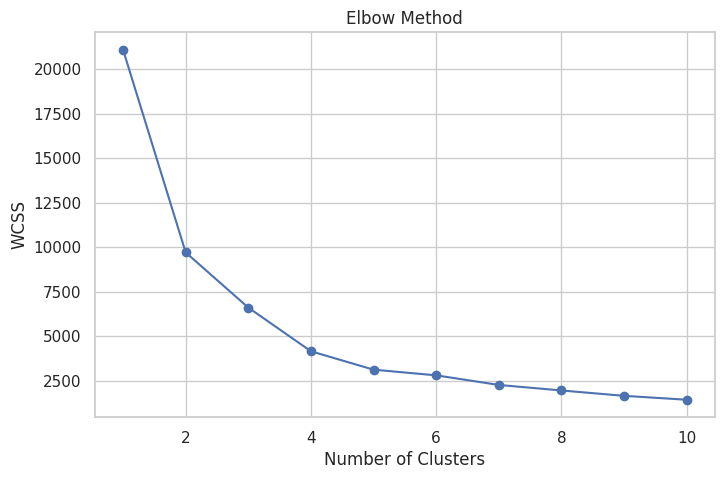

In [7]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## 9. Silhouette Score (Advanced Validation 🔥)

In [8]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.4795
K=3, Silhouette Score=0.4321
K=4, Silhouette Score=0.4723
K=5, Silhouette Score=0.4449
K=6, Silhouette Score=0.4205
K=7, Silhouette Score=0.4237
K=8, Silhouette Score=0.4126
K=9, Silhouette Score=0.4239


## 🔹 10. Apply K-Means

In [9]:

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

## 11. Cluster Distribution

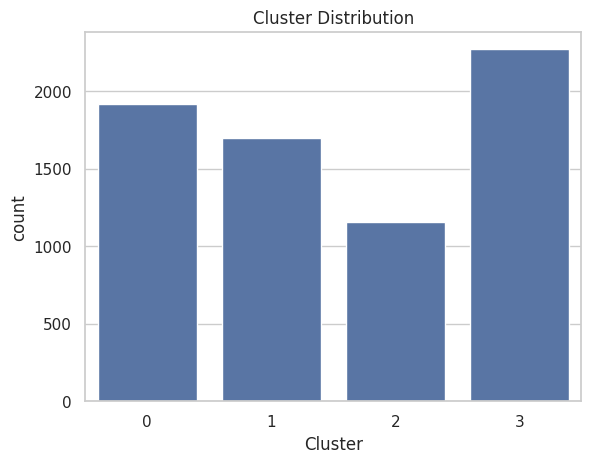

In [10]:
sns.countplot(x='Cluster', data=df)
plt.title("Cluster Distribution")
plt.show()

## 📈 12. Visualization (2D Scatter)

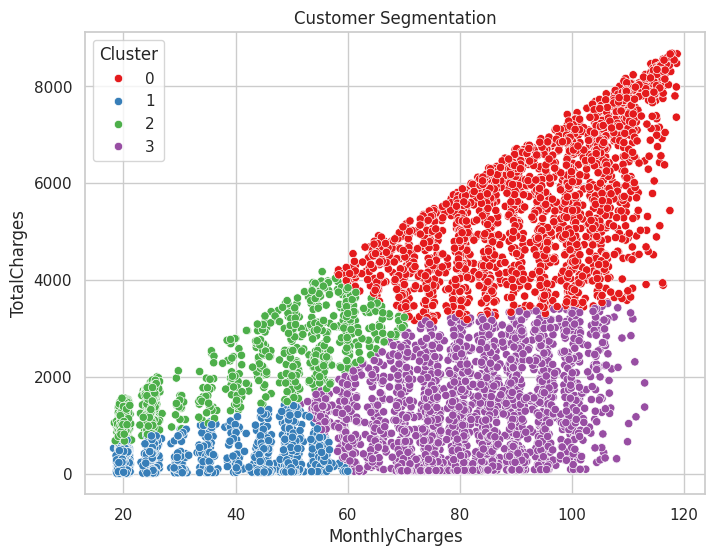

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Cluster',
    palette='Set1',
    data=df
)

plt.title("Customer Segmentation")
plt.show()

## 13. PCA Visualization

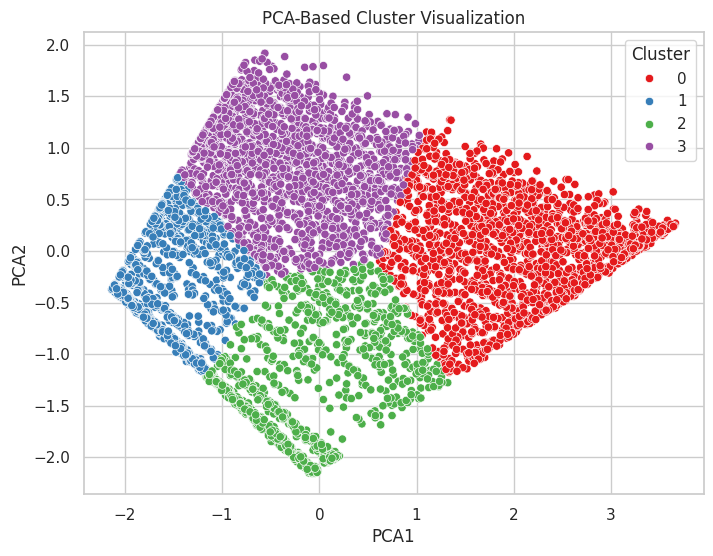

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=df)
plt.title("PCA-Based Cluster Visualization")
plt.show()

### 🔹 14. Cluster Profiling (DEEP ANALYSIS)

In [13]:
cluster_profile = df.groupby('Cluster').agg({
    'tenure': ['mean','min','max'],
    'MonthlyCharges': ['mean','min','max'],
    'TotalCharges': ['mean','min','max']
})

cluster_profile

tenure         MonthlyCharges                TotalCharges  \
              mean min max           mean    min     max         mean   
Cluster                                                                 
0        59.463185  32  72      93.206110  58.25  118.75  5536.823916   
1        10.263127   1  34      31.784336  18.25   60.15   303.578466   
2        53.564614  30  72      34.719341  18.40   70.10  1825.258153   
3        15.408550   1  42      80.769260  51.60  112.95  1249.036029   

                           
             min      max  
Cluster                    
0        3122.40  8684.80  
1          18.80  1421.75  
2         617.65  4179.20  
3          61.15  3520.75

## 15. Boxplot Analysis

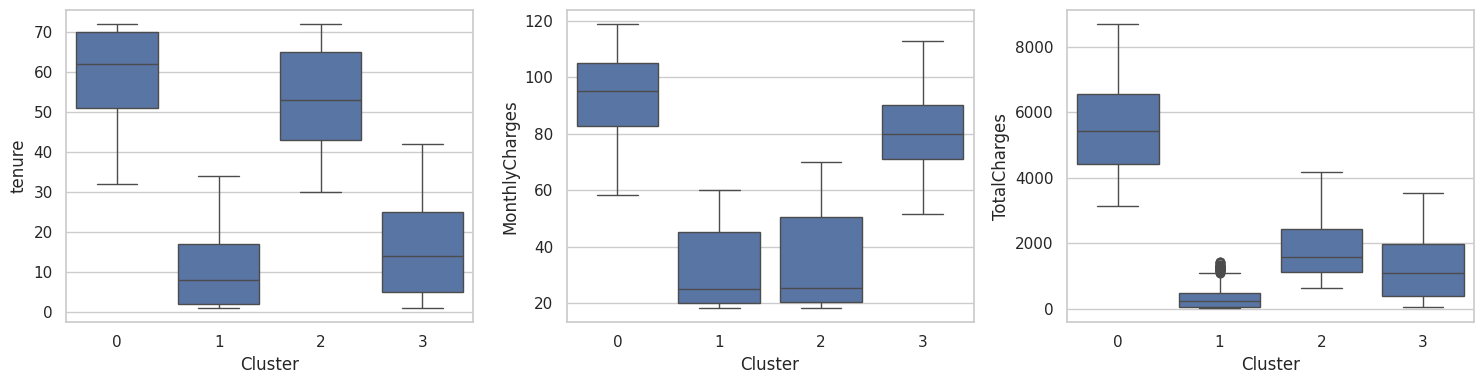

In [14]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(x='Cluster', y='tenure', data=df)

plt.subplot(1,3,2)
sns.boxplot(x='Cluster', y='MonthlyCharges', data=df)

plt.subplot(1,3,3)
sns.boxplot(x='Cluster', y='TotalCharges', data=df)

plt.tight_layout()
plt.show()

### 🔹 16. Cluster Interpretation

Cluster 0 → 🆕 New Customers
- Low tenure
- Low total charges

Cluster 1 → 💎 High-Value Loyal Customers
- High tenure
- High total spending

Cluster 2 → ⚠️ High-Risk Customers
- High monthly charges
- Low tenure

Cluster 3 → ⚖️ Moderate Customers
- Average behavior


## 🔹17. Business Insights

1. High-Risk Customers:
   - Immediate retention strategies needed
   - Offer discounts or personalized plans

2. Loyal Customers:
   - Introduce loyalty rewards
   - Premium service targeting

3. New Customers:
   - Improve onboarding experience
   - Engagement campaigns

4. Moderate Customers:
   - Upselling opportunities

## 🔹 18. Conclusion

This project successfully segmented customers into distinct groups using K-Means clustering. The insights can help telecom companies design targeted marketing, improve retention, and increase customer lifetime value.